In [1]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.transform import from_origin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Project root (since we launched Jupyter from C:\Users\aryav\GeoVision)
PROJECT_ROOT = Path(".").absolute()
print("Project root:", PROJECT_ROOT)

# Directories
data_raw_dir = PROJECT_ROOT / "data" / "raw"
data_processed_dir = PROJECT_ROOT / "data" / "processed"
data_labels_dir = PROJECT_ROOT / "data" / "labels"
models_dir = PROJECT_ROOT / "models"
outputs_maps_dir = PROJECT_ROOT / "outputs" / "maps"
outputs_reports_dir = PROJECT_ROOT / "outputs" / "reports"

for d in [data_raw_dir, data_processed_dir, data_labels_dir,
          models_dir, outputs_maps_dir, outputs_reports_dir]:
    d.mkdir(parents=True, exist_ok=True)

Project root: C:\Users\aryav\geovision\notebooks


In [2]:
import os

# Fake scene folder
scene_name = "S2A_TEST_20240101_L2A"
scene_dir = data_raw_dir / scene_name
scene_dir.mkdir(parents=True, exist_ok=True)

# Image size
H, W = 300, 300
rng = np.random.default_rng(123)

# Create 6 classes: 0=agri, 1=built_up, 2=forest, 3=water, 4=wasteland, 5=roads
# Simple blocky pattern for demonstration
true_labels = np.zeros((H, W), dtype=np.uint8)
true_labels[0:80, :] = 0         # agriculture
true_labels[80:140, 0:150] = 1   # built-up (top-left block)
true_labels[80:140, 150:] = 4    # wasteland (top-right block)
true_labels[140:220, :] = 2      # forest
true_labels[220:260, :] = 3      # water
true_labels[260:, :] = 5         # roads

def make_band(base_vals, noise_std=0.04):
    band = np.zeros((H, W), dtype=np.float32)
    for cls in range(6):
        mask = (true_labels == cls)
        band[mask] = base_vals[cls] + rng.normal(0, noise_std, size=mask.sum())
    return np.clip(band, 0, 1)

# Approximate spectral behavior for 6 classes (very simplified)
# Order: [agri, built_up, forest, water, wasteland, roads]
b2  = make_band([0.10, 0.20, 0.05, 0.08, 0.18, 0.22])
b3  = make_band([0.12, 0.22, 0.06, 0.09, 0.20, 0.24])
b4  = make_band([0.15, 0.25, 0.07, 0.10, 0.23, 0.27])
b8  = make_band([0.45, 0.30, 0.55, 0.20, 0.35, 0.32])
b11 = make_band([0.25, 0.35, 0.20, 0.18, 0.30, 0.33])
b12 = make_band([0.15, 0.25, 0.12, 0.10, 0.22, 0.20])

bands = {
    "B02": b2,
    "B03": b3,
    "B04": b4,
    "B08": b8,
    "B11": b11,
    "B12": b12,
}

transform = from_origin(0, W, 10, 10)
crs = "EPSG:4326"

profile = {
    "driver": "GTiff",
    "height": H,
    "width": W,
    "count": 1,
    "dtype": "float32",
    "crs": crs,
    "transform": transform,
}

# Save each band as a separate GeoTIFF
for name, band in bands.items():
    band_path = scene_dir / f"{name}_10m.tif"
    with rasterio.open(band_path, "w", **profile) as dst:
        dst.write(band, 1)

print("Saved fake Sentinel-2 bands to:", scene_dir)

Saved fake Sentinel-2 bands to: C:\Users\aryav\geovision\notebooks\data\raw\S2A_TEST_20240101_L2A


In [3]:
scene_dir = data_raw_dir / "S2A_TEST_20240101_L2A"

def read_band(name):
    path = scene_dir / f"{name}_10m.tif"
    with rasterio.open(path) as src:
        return src.read(1).astype("float32"), src.profile, src.transform, src.crs

b2, prof, transform, crs = read_band("B02")
b3, _, _, _ = read_band("B03")
b4, _, _, _ = read_band("B04")
b8, _, _, _ = read_band("B08")
b11, _, _, _ = read_band("B11")
b12, _, _, _ = read_band("B12")

H, W = b2.shape

# Compute indices
eps = 1e-6
ndvi = (b8 - b4) / (b8 + b4 + eps)
ndwi = (b3 - b8) / (b3 + b8 + eps)      # simple version
ndbi = (b11 - b8) / (b11 + b8 + eps)

# Stack features: 6 bands + 3 indices = 9 features
stack_features = np.stack(
    [b2, b3, b4, b8, b11, b12, ndvi, ndwi, ndbi],
    axis=-1
)

print("Feature stack shape:", stack_features.shape)  # (H, W, 9)

Feature stack shape: (300, 300, 9)


In [4]:
# Use the same true_labels from Cell 2 (still in memory)
X = stack_features.reshape(-1, stack_features.shape[-1])
y = true_labels.reshape(-1)

# Subsample for speed
n_samples = 8000
idxs = rng.choice(len(y), size=n_samples, replace=False)

X_sub = X[idxs]
y_sub = y[idxs]

print("Training data shape:", X_sub.shape, y_sub.shape)

Training data shape: (8000, 9) (8000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("Overall accuracy:", acc)
print("Kappa:", kappa)
print("\nClassification report:\n", classification_report(y_test, y_pred,
      target_names=["agriculture","built_up","forest","water","wasteland","roads"]))

Overall accuracy: 0.893125
Kappa: 0.8661171729192622

Classification report:
               precision    recall  f1-score   support

 agriculture       0.94      0.96      0.95       434
    built_up       0.75      0.69      0.72       153
      forest       0.97      0.96      0.96       436
       water       1.00      1.00      1.00       213
   wasteland       0.73      0.71      0.72       158
       roads       0.75      0.80      0.77       206

    accuracy                           0.89      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.89      0.89      0.89      1600



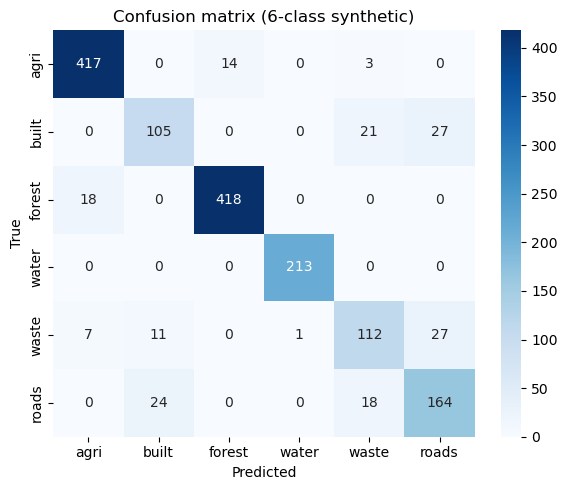

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["agri","built","forest","water","waste","roads"],
            yticklabels=["agri","built","forest","water","waste","roads"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (6-class synthetic)")
plt.tight_layout()
plt.show()

In [7]:
X_full = stack_features.reshape(-1, stack_features.shape[-1])
pred_full = rf.predict(X_full).reshape(H, W).astype("uint8")

out_cls_path = outputs_maps_dir / "test_scene_lulc.tif"

profile_cls = {
    "driver": "GTiff",
    "height": H,
    "width": W,
    "count": 1,
    "dtype": "uint8",
    "crs": crs,
    "transform": transform,
    "compress": "lzw",
}

with rasterio.open(out_cls_path, "w", **profile_cls) as dst:
    dst.write(pred_full, 1)

print("Saved classified map to:", out_cls_path)

Saved classified map to: C:\Users\aryav\geovision\notebooks\outputs\maps\test_scene_lulc.tif


In [8]:
unique, counts = np.unique(pred_full, return_counts=True)
total_pixels = pred_full.size

stats = []
for cls_id, cnt in zip(unique, counts):
    pct = cnt / total_pixels * 100
    stats.append({
        "class_id": int(cls_id),
        "pixel_count": int(cnt),
        "percentage": round(pct, 2)
    })

import pandas as pd
df_stats = pd.DataFrame(stats)

class_names = {
    0: "agriculture",
    1: "built_up",
    2: "forest",
    3: "water",
    4: "wasteland",
    5: "roads",
}
df_stats["class_name"] = df_stats["class_id"].map(class_names)

df_stats

,class_id,pixel_count,percentage,class_name
0,0,24193,26.88,agriculture
1,1,8343,9.27,built_up
2,2,24012,26.68,forest
3,3,12001,13.33,water
4,4,8740,9.71,wasteland
5,5,12711,14.12,roads


In [9]:
model_path = models_dir / "rf_6class_synthetic.pkl"
joblib.dump(rf, model_path)
print("Model saved to:", model_path)

Model saved to: C:\Users\aryav\geovision\notebooks\models\rf_6class_synthetic.pkl
